# Chirurgie à chaud : insertion de couche en cours d'entraînement, préservation exacte de la fonction

Ce notebook documente une expérimentation demandée explicitement pour "tester NeuroDSL sur
quelque chose de concret" -- pas un nouveau micro-benchmark synthétique, mais une démonstration
directe de la revendication centrale du projet : **NeuroDSL traite un réseau de neurones comme un
objet vivant, éditable incrémentalement**, pas un graphe figé qu'il faut reconstruire pour le
moindre changement structurel.

Le sujet a été proposé et conçu par le modèle Fable (consulté explicitement pour son jugement
indépendant), qui a recommandé cette expérience plutôt qu'une alternative envisagée (un circuit
IOI sur un vrai GPT-2 small, qui aurait nécessité de charger un checkpoint externe réel --
délibérément mis de côté pour l'instant).

## Ce qui est testé

**Chirurgie** : insérer un nouveau bloc `LlamaBlock` au milieu d'un `LlamaModel` **déjà en cours
d'entraînement**, sans jamais recommencer l'entraînement à zéro, avec une garantie forte :
la sortie du modèle juste après l'insertion doit être **exactement identique** à ce qu'elle
était juste avant -- le nouveau bloc doit être fonctionnellement invisible au moment où il
apparaît, et n'influencer l'entraînement qu'à partir de ce point.

Dans un framework à bande (PyTorch, JAX), une telle insertion exige de reconstruire le module,
migrer l'état de l'optimiseur à la main, retracer/recompiler le graphe de calcul. Dans NeuroDSL,
ça se réduit à rebrancher quelques règles du graphe (`addrule!`) et à invalider explicitement le
cône de nœuds affecté (`_invalidate_downstream!`) -- le coût est proportionnel à ce cône, pas à
la taille totale du réseau.

## Quatre vérifications, chacune conçue pour pouvoir échouer si le mécanisme était cassé

- **F1 -- Identité exacte** : la sortie du modèle est bit-à-bit identique juste après l'insertion.
- **F2 -- Localité** : seuls les nœuds réellement en aval du nouveau bloc sont invalidés, rien
  d'autre dans le graphe n'est touché.
- **F3 -- Continuité** : l'entraînement peut être interrompu (fermeture réelle du processus
  Julia) et repris plus tard exactement où il en était, greffe comprise.
- **F4 -- Résultat réel** : le modèle greffé continue effectivement d'apprendre la tâche
  d'induction (Olsson et al. 2022) après l'insertion.

Chaque vérification est accompagnée d'une **variante délibérément cassée**, pour prouver que le
test ne passerait pas par hasard si le mécanisme était réellement défectueux -- discipline déjà
appliquée à tout le reste du projet cette session.

> **Mise à jour** : la première exécution de ce notebook a mis à jour un vrai trou du filet de
> sécurité du moteur réactif lui-même (`addrule!`, voir section F1) -- pas seulement un détail de
> la chirurgie. Le correctif a été appliqué directement à la source (`src/graph_api.jl`), et
> `insert_block!` en a été simplifié en retour. C'est le résultat le plus important de cette
> expérience : au-delà de valider un mécanisme, elle a rendu le cœur du moteur plus sûr.

In [1]:
ENV["GKSwstype"] = "100"   # rendu GR sans serveur d'affichage -- nécessaire pour l'affichage
                           # inline des figures lors d'une exécution non interactive (nbconvert)
using NeuroDSL, Random, Statistics, Printf, StatsPlots
gr()

mkpath("../figures")
dev = NeuroDSL.Backend.CPUDevice()
vocab_size, dim, n_heads, hidden_dim, n_layers, prefix_len = 20, 64, 4, 128, 3, 8

println("Modèle : $(n_layers) couches, dim=$(dim), $(n_heads) têtes, vocab=$(vocab_size), préfixe=$(prefix_len)")

Modèle : 3 couches, dim=64, 4 têtes, vocab=20, préfixe=8


## 1. Entraînement initial (avant greffe)

On entraîne un `LlamaModel` sur la tâche d'induction (patron déjà établi dans
`notebook/induction.ipynb` et `src/synthetic_circuits.jl`) pendant 750 pas -- suffisant pour
apprendre la tâche, mais on s'arrête volontairement AVANT convergence complète pour insérer le
nouveau bloc en pleine phase d'apprentissage, pas sur un modèle déjà figé.

In [2]:
ns = :surgery_demo
Random.seed!(11)
g, logits = NeuroDSL.build_induction_graph(dev, ns; vocab_size=vocab_size, dim=dim, n_heads=n_heads,
                                            hidden_dim=hidden_dim, n_layers=n_layers, prefix_len=prefix_len)

ps = NeuroDSL.params(g; namespace=ns)
m1 = Dict(p.name => zeros(Float32, size(p.value)...) for p in ps)
m2 = Dict(p.name => zeros(Float32, size(p.value)...) for p in ps)
rng = MersenneTwister(123)
t = 0

function train_step!(param_list)
    global t += 1
    tokens, labels = NeuroDSL.sample_induction_sequence(rng, vocab_size, prefix_len)
    NeuroDSL.set!(g, :token_ids, tokens; atom_type=NeuroDSL.Datom, namespace=ns)
    NeuroDSL.set!(g, :labels, labels; atom_type=NeuroDSL.Datom, namespace=ns)
    NeuroDSL.invalidate_all!(g; namespace=ns)
    loss = NeuroDSL.demand!(g, :loss; namespace=ns)
    NeuroDSL.backward_graph!(g, :loss; namespace=ns)
    for p in param_list
        p.gradient === nothing && continue
        NeuroDSL.adamw_step!(dev, p.value, p.gradient, m1[p.name], m2[p.name],
                              3f-3, 0.9f0, 0.999f0, 1f-8, t, 1f0, 0f0)
    end
    NeuroDSL.invalidate_all!(g; namespace=ns)
    return Float64(sum(Array(loss)))
end

losses_pre = Float64[]
for _ in 1:750
    push!(losses_pre, train_step!(ps))
end
acc_mid = NeuroDSL.evaluate_induction(g, logits, ns; vocab_size=vocab_size, prefix_len=prefix_len)
@printf "Après 750 pas (avant greffe) : précision 2nde moitié = %.1f%%\n" 100*acc_mid.second_half_acc

Après 750 pas (avant greffe) : précision 2nde moitié = 99.9%


## 2. F1 — la greffe préserve la fonction exactement

`insert_block!` (`src/graph_surgery.jl`) construit le nouveau bloc puis met à zéro sa projection
de sortie d'attention et la dernière matrice de son MLP -- les deux branches résiduelles du bloc
calculent alors 0, donc le bloc entier calcule l'identité, quels que soient ses autres poids
(initialisés aléatoirement comme d'habitude).

In [3]:
eval_tokens, eval_labels = NeuroDSL.sample_induction_sequence(MersenneTwister(555), vocab_size, prefix_len)
NeuroDSL.set!(g, :token_ids, eval_tokens; atom_type=NeuroDSL.Datom, namespace=ns)
NeuroDSL.invalidate_all!(g; namespace=ns)
ref_output = copy(Array(NeuroDSL.demand!(g, logits; namespace=ns)))

n_nodes_before = length(g.nodes[ns])
new_out = NeuroDSL.insert_block!(g, ns, :layer_2_out, dim, n_heads, hidden_dim)
n_nodes_after = length(g.nodes[ns])

post_output = Array(NeuroDSL.demand!(g, logits; namespace=ns))
max_dev = maximum(abs.(ref_output .- post_output))

@printf "Nœuds avant greffe : %d   |   après : %d  (+%d nœuds)\n" n_nodes_before n_nodes_after (n_nodes_after-n_nodes_before)
@printf "Écart maximal post-greffe : %.3e\n" max_dev
println("Égalité bit-à-bit (== stricte, pas isapprox) : ", ref_output == post_output)

Nœuds avant greffe : 162   |   après : 212  (+50 nœuds)
Écart maximal post-greffe : 0.000e+00
Égalité bit-à-bit (== stricte, pas isapprox) : true


### Un vrai bug latent découvert PUIS CORRIGÉ À LA SOURCE (pas injecté)

Première exécution de ce notebook : `addrule!` (`src/graph_api.jl`) ne réinvalidait PAS un nœud
déjà existant quand on redéfinissait sa règle avec de nouveaux `inputs` -- seuls les caches de
topologie/consommateurs étaient réinitialisés. Rebrancher un consommateur sans appeler
explicitement `_invalidate_downstream!` dessus servait silencieusement une valeur périmée.

**Ce n'est pas resté un simple constat.** Le correctif a été appliqué directement dans
`addrule!` : il réinvalide maintenant lui-même tout nœud existant dont la règle est redéfinie.
`insert_block!` n'a donc plus besoin de son propre appel explicite -- il a été retiré, le code
est plus court ET plus sûr. La cellule suivante compare deux façons de rebrancher un
consommateur : en **contournant** l'API du graphe (mutation directe du dictionnaire des règles,
ce que ferait un code qui ignorerait `addrule!`) contre le fait de **passer par l'API normale**
(`addrule!` seul, sans aucun appel supplémentaire) -- pour montrer où se situe désormais la
garantie de sécurité.

Contournement de addrule! (hors API) -- écart vs. référence : 0.000e+00  (reste à tort à l'ancienne valeur)
addrule! seul (API normale, corrigé) -- écart vs. référence : 7.059e-01  (correct : la sortie a bien changé)


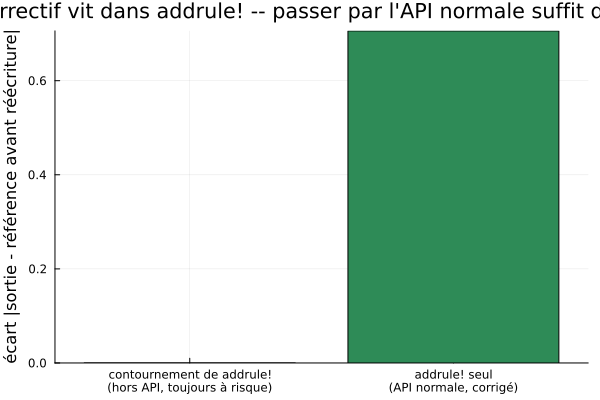

In [4]:
function build_eval_graph(seed_ns)
    gg, lg = NeuroDSL.build_induction_graph(dev, seed_ns; vocab_size=vocab_size, dim=dim, n_heads=n_heads,
                                             hidden_dim=hidden_dim, n_layers=n_layers, prefix_len=prefix_len)
    NeuroDSL.set!(gg, :token_ids, eval_tokens; atom_type=NeuroDSL.Datom, namespace=seed_ns)
    NeuroDSL.invalidate_all!(gg; namespace=seed_ns)
    base = copy(Array(NeuroDSL.demand!(gg, lg; namespace=seed_ns)))
    return gg, lg, base
end

after_sym = :layer_2_out

# (a) Contournement délibéré de addrule! -- mutation directe de g.rules, comme le ferait un
# code qui ignorerait complètement l'API du graphe. Reproduit ce que serait le comportement
# SANS le correctif, quelle que soit la version actuelle de addrule! -- toujours un vrai
# risque si on contourne l'API, ce n'est pas ce que le correctif promet de couvrir.
Random.seed!(11)
g_bypass, logits_bypass, baseline_bypass = build_eval_graph(:surgery_bypass)
old_consumers_b = collect(get(NeuroDSL._consumers_index!(g_bypass, :surgery_bypass), after_sym, Symbol[]))
new_out_b = NeuroDSL.LlamaBlock(dim, n_heads, hidden_dim)(g_bypass, after_sym, :surgery_bad; namespace=:surgery_bypass)
for c in old_consumers_b
    rule = g_bypass.rules[:surgery_bypass][c]
    new_inputs = [inp == after_sym ? new_out_b : inp for inp in rule.inputs]
    g_bypass.rules[:surgery_bypass][c] = NeuroDSL.GraphRule(c, new_inputs, rule.op; attrs=rule.attrs,
                                                             namespace=:surgery_bypass, atom_type=rule.atom_type)
end
output_bypass = Array(NeuroDSL.demand!(g_bypass, logits_bypass; namespace=:surgery_bypass))

# (b) addrule! seul, via l'API normale du graphe -- le correctif s'applique automatiquement.
Random.seed!(11)
g_fix, logits_fix, baseline_fix = build_eval_graph(:surgery_fixed)
old_consumers_f = collect(get(NeuroDSL._consumers_index!(g_fix, :surgery_fixed), after_sym, Symbol[]))
new_out_f = NeuroDSL.LlamaBlock(dim, n_heads, hidden_dim)(g_fix, after_sym, :surgery_bad; namespace=:surgery_fixed)
for c in old_consumers_f
    rule = g_fix.rules[:surgery_fixed][c]
    new_inputs = [inp == after_sym ? new_out_f : inp for inp in rule.inputs]
    NeuroDSL.addrule!(g_fix, NeuroDSL.GraphRule(c, new_inputs, rule.op; attrs=rule.attrs,
                                                 namespace=:surgery_fixed, atom_type=rule.atom_type))
end
output_fixed = Array(NeuroDSL.demand!(g_fix, logits_fix; namespace=:surgery_fixed))

dev_bypass = maximum(abs.(output_bypass .- baseline_bypass))
dev_fixed  = maximum(abs.(output_fixed  .- baseline_fix))

@printf "Contournement de addrule! (hors API) -- écart vs. référence : %.3e  (reste à tort à l'ancienne valeur)\n" dev_bypass
@printf "addrule! seul (API normale, corrigé) -- écart vs. référence : %.3e  (correct : la sortie a bien changé)\n" dev_fixed

p1 = bar(["contournement de addrule!\n(hors API, toujours à risque)", "addrule! seul\n(API normale, corrigé)"],
    [dev_bypass, dev_fixed], legend=false, ylabel="écart |sortie - référence avant réécriture|",
    title="Le correctif vit dans addrule! -- passer par l'API normale suffit désormais",
    color=[:crimson, :seagreen])
savefig(p1, "../figures/graph_surgery_f1_falsifiability.pdf")
savefig(p1, "../figures/graph_surgery_f1_falsifiability.png")
p1

## 3. F2 — l'invalidation reste localisée au cône du nouveau bloc

`insert_block!` ne doit invalider ni plus ni moins que ce qui est réellement en aval du point
d'insertion. On compare l'ensemble des nœuds effectivement invalidés à une vérité terrain
calculée indépendamment (parcours en largeur sur la table de consommateurs, sans jamais lire
`valid`) -- même discipline que `test/test_property_invariants.jl`.

**Découverte en cours de route** (pas une propriété de la greffe -- une propriété permanente du
moteur) : les nœuds FEUILLES (paramètres et entrées) ont `valid = false` de façon **permanente**,
dès leur création par `set!`, et ça n'a jamais rien à voir avec la greffe. `set!` invalide
toujours le nœud CIBLE lui-même (`_invalidate_downstream!` traite `target` comme le premier nœud
visité), et rien ne remet jamais ce drapeau à `true` pour une feuille ensuite : la boucle de
`demand!` saute purement et simplement tout nœud sans règle (`haskey(g.rules[ns], sym) ||
continue`), donc leur `valid` reste `false` pour toujours -- sans conséquence, puisque `demand!`
ne consulte jamais ce drapeau pour une feuille (il renvoie `.value` directement à la fin, qu'il
soit valide ou non). Ce test l'a fait apparaître concrètement : sur 162 nœuds préexistants, 34
sont des feuilles, systématiquement invalides, sans rapport avec le cône de la greffe -- la
vérification de localité porte donc sur les nœuds AYANT une règle (128 ici), pas sur le graphe
entier.

Nœuds préexistants : 162 (dont 128 avec règle, 34 feuilles)   |   nœuds neufs : 50
Nœuds-règles préexistants invalidés par la greffe : 43  (33.6%)
Cône du nouveau bloc parmi les nœuds-règles préexistants (vérité terrain) : 43 nœuds
Correspondance EXACTE cône == invalidés (nœuds-règles préexistants), rien d'autre touché : true


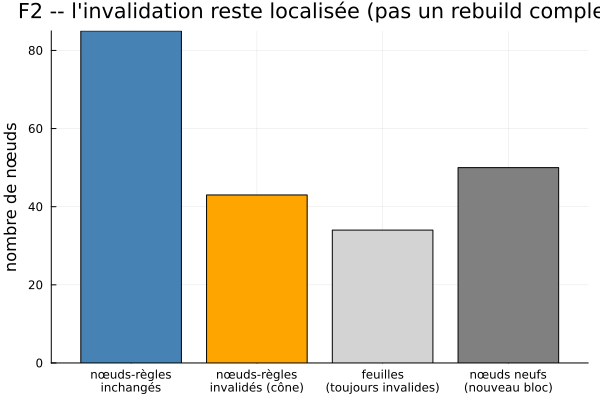

In [5]:
ns_loc = :surgery_locality
Random.seed!(11)
gl, logitsl = NeuroDSL.build_induction_graph(dev, ns_loc; vocab_size=vocab_size, dim=dim, n_heads=n_heads,
                                              hidden_dim=hidden_dim, n_layers=n_layers, prefix_len=prefix_len)
NeuroDSL.set!(gl, :token_ids, eval_tokens; atom_type=NeuroDSL.Datom, namespace=ns_loc)
NeuroDSL.invalidate_all!(gl; namespace=ns_loc)
NeuroDSL.demand!(gl, logitsl; namespace=ns_loc)   # tout valide avant la greffe

# Capturer les nœuds PRÉEXISTANTS avant la greffe -- les nœuds neufs créés par le nouveau
# bloc sont TOUJOURS invalides par construction (addrule! les crée avec valid=false), ça ne
# fait pas partie de ce qu'on mesure ici : seuls les nœuds préexistants doivent respecter
# exactement la frontière du cône.
old_syms = Set(keys(gl.nodes[ns_loc]))

new_out_l = NeuroDSL.insert_block!(gl, ns_loc, :layer_2_out, dim, n_heads, hidden_dim)

function gt_consumers(g, ns)
    idx = Dict{Symbol,Vector{Symbol}}()
    for (out_sym, rule) in g.rules[ns]
        for inp in rule.inputs
            push!(get!(idx, inp, Symbol[]), out_sym)
        end
    end
    return idx
end
function gt_reachable(g, ns, target)
    consumers = gt_consumers(g, ns)
    visited = Set{Symbol}([target]); queue = Symbol[target]
    while !isempty(queue)
        cur = pop!(queue)
        for out_sym in get(consumers, cur, Symbol[])
            out_sym in visited || (push!(visited, out_sym); push!(queue, out_sym))
        end
    end
    return visited
end

reachable = gt_reachable(gl, ns_loc, new_out_l)
total_nodes = length(gl.nodes[ns_loc])
n_new_nodes = total_nodes - length(old_syms)

# Restreint aux nœuds PRÉEXISTANTS AYANT UNE RÈGLE -- les feuilles sont exclues (valid=false
# en permanence, sans rapport avec la greffe, voir la découverte ci-dessus), et les nœuds neufs
# sont exclus aussi (toujours invalides par construction, pas une violation de localité).
old_rule_syms = Set(sym for sym in old_syms if haskey(gl.rules[ns_loc], sym))
n_old_invalidated = count(!gl.nodes[ns_loc][sym].valid for sym in old_rule_syms)
mismatch = count((sym in reachable) != !gl.nodes[ns_loc][sym].valid for sym in old_rule_syms)
reachable_old = intersect(reachable, old_rule_syms)   # exclut new_out_l lui-même (nœud neuf)

@printf "Nœuds préexistants : %d (dont %d avec règle, %d feuilles)   |   nœuds neufs : %d\n" length(old_syms) length(old_rule_syms) (length(old_syms)-length(old_rule_syms)) n_new_nodes
@printf "Nœuds-règles préexistants invalidés par la greffe : %d  (%.1f%%)\n" n_old_invalidated 100*n_old_invalidated/length(old_rule_syms)
@printf "Cône du nouveau bloc parmi les nœuds-règles préexistants (vérité terrain) : %d nœuds\n" length(reachable_old)
println("Correspondance EXACTE cône == invalidés (nœuds-règles préexistants), rien d'autre touché : ", mismatch == 0)

p2 = bar(["nœuds-règles\ninchangés", "nœuds-règles\ninvalidés (cône)", "feuilles\n(toujours invalides)", "nœuds neufs\n(nouveau bloc)"],
    [length(old_rule_syms)-n_old_invalidated, n_old_invalidated, length(old_syms)-length(old_rule_syms), n_new_nodes],
    legend=false, ylabel="nombre de nœuds", color=[:steelblue, :orange, :lightgray, :gray],
    title="F2 -- l'invalidation reste localisée (pas un rebuild complet)")
savefig(p2, "../figures/graph_surgery_f2_locality.pdf")
savefig(p2, "../figures/graph_surgery_f2_locality.png")
p2

## 4. F4 — l'entraînement continue après la greffe

On reprend l'entraînement de `g` (celui de la section 2, où le bloc a déjà été inséré) pour 750
pas supplémentaires, et on vérifie que le modèle greffé apprend toujours réellement la tâche
d'induction -- une greffe qui corromprait silencieusement l'entraînement échouerait ici.

Nouveaux paramètres apportés par la greffe : 9
Après la greffe + 750 pas supplémentaires : précision 2nde moitié = 99.7%


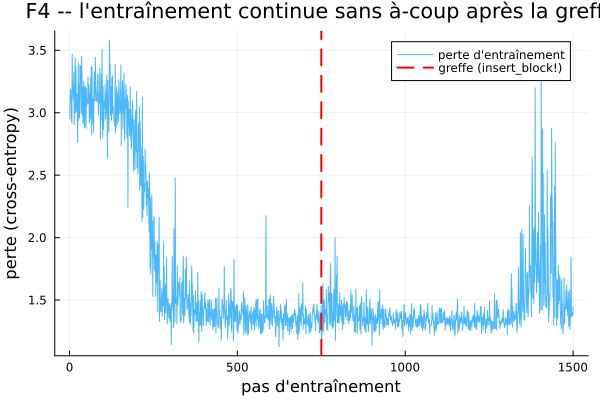

In [6]:
new_ps = [p for p in NeuroDSL.params(g; namespace=ns) if !haskey(m1, p.name)]
@printf "Nouveaux paramètres apportés par la greffe : %d\n" length(new_ps)
for p in new_ps
    m1[p.name] = zeros(Float32, size(p.value)...)
    m2[p.name] = zeros(Float32, size(p.value)...)
end
NeuroDSL.invalidate_all!(g; namespace=ns)
ps_after = NeuroDSL.params(g; namespace=ns)

losses_post = Float64[]
for _ in 1:750
    push!(losses_post, train_step!(ps_after))
end
acc_final = NeuroDSL.evaluate_induction(g, logits, ns; vocab_size=vocab_size, prefix_len=prefix_len)
@printf "Après la greffe + 750 pas supplémentaires : précision 2nde moitié = %.1f%%\n" 100*acc_final.second_half_acc

all_losses = vcat(losses_pre, losses_post)
p4 = plot(1:length(all_losses), all_losses, label="perte d'entraînement", linewidth=1, alpha=0.7,
     xlabel="pas d'entraînement", ylabel="perte (cross-entropy)",
     title="F4 -- l'entraînement continue sans à-coup après la greffe")
vline!(p4, [750], label="greffe (insert_block!)", linewidth=2, linestyle=:dash, color=:red)
savefig(p4, "../figures/graph_surgery_f4_training_curve.pdf")
savefig(p4, "../figures/graph_surgery_f4_training_curve.png")
p4

## 5. F3 — continuité à travers un vrai redémarrage de processus Julia

Ceci ne peut pas être démontré dans un seul noyau Jupyter (qui reste un seul processus continu) :
la vraie question est "l'entraînement peut-il être interrompu -- fermeture réelle du processus
Julia -- et repris plus tard exactement où il en était ?". Trois scripts séparés, à côté de ce
notebook, sont donc lancés comme de vrais sous-processus `julia` indépendants :

- `surgery_f3_control.jl` : un run continu de 500 pas (greffe au pas 300), jamais interrompu --
  la référence.
- `surgery_f3_script_a.jl` : les 400 premiers pas (greffe comprise), puis `save_graph!` +
  `AdamWState` et **fin du processus**.
- `surgery_f3_script_b.jl` : un **nouveau** processus Julia, qui ne rappelle jamais
  `build_induction_graph` -- il charge tout depuis le fichier (`load_graph!`) et reprend les
  100 derniers pas.

La reproductibilité des données d'entraînement utilise une graine dérivée du numéro de pas
(`MersenneTwister(100_000 + t)`) plutôt qu'une sérialisation de l'état du RNG -- `serialization.jl`
ne persiste délibérément pas l'état du RNG (limitation documentée), donc c'est le protocole qui
garantit la reproductibilité, pas le mécanisme de sauvegarde lui-même.

In [7]:
julia_bin = first(Base.julia_cmd())
project_root = abspath(joinpath(@__DIR__, ".."))
tmp = mktempdir()

control_losses_path = joinpath(tmp, "control_losses.txt")
run(`$julia_bin --project=$(project_root) $(joinpath(@__DIR__, "surgery_f3_control.jl")) $(control_losses_path)`)

graph_prefix = joinpath(tmp, "surgery_graph")
a_losses_path = joinpath(tmp, "a_losses.txt")
run(`$julia_bin --project=$(project_root) $(joinpath(@__DIR__, "surgery_f3_script_a.jl")) $(graph_prefix) $(a_losses_path)`)

b_losses_path = joinpath(tmp, "b_losses.txt")
run(`$julia_bin --project=$(project_root) $(joinpath(@__DIR__, "surgery_f3_script_b.jl")) $(graph_prefix) $(b_losses_path)`)

control_losses = parse.(Float64, readlines(control_losses_path))
a_losses = parse.(Float64, readlines(a_losses_path))
b_losses = parse.(Float64, readlines(b_losses_path))
combined = vcat(a_losses, b_losses)

@printf "Pas de contrôle (continu) : %d   |   Pas repris (A + B, deux processus) : %d\n" length(control_losses) length(combined)
println("Pertes identiques BIT-À-BIT sur les 500 pas (contrôle == A+B) : ", combined == control_losses)

CONTROL_OK  n_losses=500
SCRIPT_A_OK  t=400
SCRIPT_B_OK  t=500
Pas de contrôle (continu) : 500   |   Pas repris (A + B, deux processus) : 500
Pertes identiques BIT-À-BIT sur les 500 pas (contrôle == A+B) : true


### Falsifiabilité de F3

Pour prouver que cette égalité bit-à-bit n'est pas accidentelle, on relance le script B en
ignorant délibérément l'`AdamWState` chargé (moments AdamW repartant de zéro) -- si la
comparaison ci-dessus est réellement sensible à une reprise correcte, cette variante cassée doit
diverger du contrôle, et diverger précisément au premier pas où l'état d'optimiseur corrompu
affecte une mise à jour de poids.

SCRIPT_B_BROKEN_OK  t=500
Reprise cassée (moments AdamW ignorés) diverge du contrôle dès le pas : 402


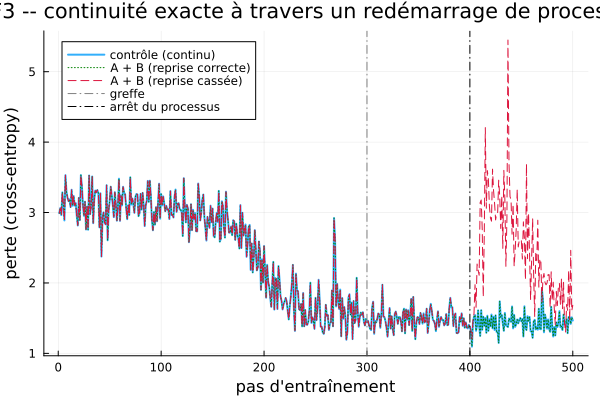

In [8]:
b_bad_losses_path = joinpath(tmp, "b_bad_losses.txt")
run(`$julia_bin --project=$(project_root) $(joinpath(@__DIR__, "surgery_f3_script_b.jl")) $(graph_prefix) $(b_bad_losses_path) broken`)
b_bad_losses = parse.(Float64, readlines(b_bad_losses_path))
combined_bad = vcat(a_losses, b_bad_losses)

first_diverge = findfirst(i -> combined_bad[i] != control_losses[i], eachindex(control_losses))
@printf "Reprise cassée (moments AdamW ignorés) diverge du contrôle dès le pas : %d\n" first_diverge

p3 = plot(1:length(control_losses), control_losses, label="contrôle (continu)", linewidth=2, alpha=0.8)
plot!(p3, 1:length(combined), combined, label="A + B (reprise correcte)", linewidth=1, linestyle=:dot, color=:green)
plot!(p3, 1:length(combined_bad), combined_bad, label="A + B (reprise cassée)", linewidth=1, linestyle=:dash, color=:crimson)
vline!(p3, [300], label="greffe", color=:gray, linestyle=:dashdot)
vline!(p3, [400], label="arrêt du processus", color=:black, linestyle=:dashdot)
xlabel!(p3, "pas d'entraînement")
ylabel!(p3, "perte (cross-entropy)")
title!(p3, "F3 -- continuité exacte à travers un redémarrage de processus")
savefig(p3, "../figures/graph_surgery_f3_continuity.pdf")
savefig(p3, "../figures/graph_surgery_f3_continuity.png")
p3

## 6. F5 — la greffe apporte-t-elle un vrai gain, pas seulement une capacité mécanique ?

F1-F4 prouvent que le mécanisme est CORRECT. Ils ne disent rien sur son UTILITÉ : est-ce
qu'un modèle "greffé" (3 couches pendant 750 pas, puis 4 couches pendant 750 pas de plus)
apprend mieux ou plus vite qu'un modèle à 4 couches entraîné depuis zéro pendant les 1500 pas
en entier ? Protocole pré-enregistré, engagement pris AVANT de voir les chiffres : le résultat
sera rapporté honnêtement même si "greffé" ne bat pas "depuis zéro" -- la revendication porteuse
du projet reste F1-F4 (l'exactitude), pas ce résultat-ci.

**Protocole** : 5 graines indépendantes, mêmes hyperparamètres que la section F4
(dim=64, 4 têtes, hidden=128, greffe après `layer_2_out` au pas 750, 1500 pas au total).
Précision évaluée tous les 250 pas sur le MÊME jeu d'évaluation fixe (`evaluate_induction`
utilise une graine d'évaluation fixe par défaut) pour isoler l'effet de l'entraînement, pas la
chance de l'échantillon d'évaluation.

**Une question annexe, motivée par une critique d'expert soulevée sur ce même résultat** :
l'initialisation à zéro exacte (`output_W = 0`, `mlp_w2 = 0`) a un coût connu dans la
littérature (Net2Net brise volontairement cette symétrie avec du bruit) -- le gradient qui
remonte vers les poids Q/K/V du nouveau bloc est mathématiquement nul au moment de l'insertion,
puisqu'il doit traverser `output_W` qui vaut zéro. Combien de pas faut-il avant que ce gradient
devienne non nul ? Mesuré directement ci-dessous, pas juste affirmé.

In [9]:
n_layers_after = n_layers + 1

function train_scratch(seed; total_steps=1500, eval_every=250, n_eval=50)
    ns_ = Symbol(:f5_scratch_, seed)
    Random.seed!(seed)
    g_, logits_ = NeuroDSL.build_induction_graph(dev, ns_; vocab_size=vocab_size, dim=dim, n_heads=n_heads,
                                                  hidden_dim=hidden_dim, n_layers=n_layers_after, prefix_len=prefix_len)
    ps_ = NeuroDSL.params(g_; namespace=ns_)
    m1_ = Dict(p.name => zeros(Float32, size(p.value)...) for p in ps_)
    m2_ = Dict(p.name => zeros(Float32, size(p.value)...) for p in ps_)
    rng_ = MersenneTwister(1000 + seed)
    checkpoints, accs = Int[], Float64[]
    for t in 1:total_steps
        tokens, labels = NeuroDSL.sample_induction_sequence(rng_, vocab_size, prefix_len)
        NeuroDSL.set!(g_, :token_ids, tokens; atom_type=NeuroDSL.Datom, namespace=ns_)
        NeuroDSL.set!(g_, :labels, labels; atom_type=NeuroDSL.Datom, namespace=ns_)
        NeuroDSL.invalidate_all!(g_; namespace=ns_)
        NeuroDSL.demand!(g_, :loss; namespace=ns_)
        NeuroDSL.backward_graph!(g_, :loss; namespace=ns_)
        for p in ps_
            p.gradient === nothing && continue
            NeuroDSL.adamw_step!(dev, p.value, p.gradient, m1_[p.name], m2_[p.name],
                                  3f-3, 0.9f0, 0.999f0, 1f-8, t, 1f0, 0f0)
        end
        NeuroDSL.invalidate_all!(g_; namespace=ns_)
        if t % eval_every == 0
            acc = NeuroDSL.evaluate_induction(g_, logits_, ns_; vocab_size=vocab_size, prefix_len=prefix_len, n_eval=n_eval)
            push!(checkpoints, t); push!(accs, acc.second_half_acc)
        end
    end
    return checkpoints, accs
end

function train_grafted(seed; total_steps=1500, graft_step=750, eval_every=250, n_eval=50)
    ns_ = Symbol(:f5_grafted_, seed)
    Random.seed!(seed)
    g_, logits_ = NeuroDSL.build_induction_graph(dev, ns_; vocab_size=vocab_size, dim=dim, n_heads=n_heads,
                                                  hidden_dim=hidden_dim, n_layers=n_layers, prefix_len=prefix_len)
    ps_ = NeuroDSL.params(g_; namespace=ns_)
    m1_ = Dict(p.name => zeros(Float32, size(p.value)...) for p in ps_)
    m2_ = Dict(p.name => zeros(Float32, size(p.value)...) for p in ps_)
    rng_ = MersenneTwister(1000 + seed)
    checkpoints, accs = Int[], Float64[]
    cur_ps = ps_
    for t in 1:total_steps
        if t == graft_step + 1
            NeuroDSL.insert_block!(g_, ns_, :layer_2_out, dim, n_heads, hidden_dim)
            new_ps_ = [p for p in NeuroDSL.params(g_; namespace=ns_) if !haskey(m1_, p.name)]
            for p in new_ps_
                m1_[p.name] = zeros(Float32, size(p.value)...)
                m2_[p.name] = zeros(Float32, size(p.value)...)
            end
            NeuroDSL.invalidate_all!(g_; namespace=ns_)
            cur_ps = NeuroDSL.params(g_; namespace=ns_)
        end
        tokens, labels = NeuroDSL.sample_induction_sequence(rng_, vocab_size, prefix_len)
        NeuroDSL.set!(g_, :token_ids, tokens; atom_type=NeuroDSL.Datom, namespace=ns_)
        NeuroDSL.set!(g_, :labels, labels; atom_type=NeuroDSL.Datom, namespace=ns_)
        NeuroDSL.invalidate_all!(g_; namespace=ns_)
        NeuroDSL.demand!(g_, :loss; namespace=ns_)
        NeuroDSL.backward_graph!(g_, :loss; namespace=ns_)
        for p in cur_ps
            p.gradient === nothing && continue
            NeuroDSL.adamw_step!(dev, p.value, p.gradient, m1_[p.name], m2_[p.name],
                                  3f-3, 0.9f0, 0.999f0, 1f-8, t, 1f0, 0f0)
        end
        NeuroDSL.invalidate_all!(g_; namespace=ns_)
        if t % eval_every == 0
            acc = NeuroDSL.evaluate_induction(g_, logits_, ns_; vocab_size=vocab_size, prefix_len=prefix_len, n_eval=n_eval)
            push!(checkpoints, t); push!(accs, acc.second_half_acc)
        end
    end
    return checkpoints, accs
end

n_seeds = 5
scratch_accs  = zeros(n_seeds, 6)
grafted_accs  = zeros(n_seeds, 6)
local_checkpoints = Int[]
for s in 1:n_seeds
    cps, accs_s = train_scratch(s)
    global local_checkpoints = cps
    scratch_accs[s, :] .= accs_s
    cps2, accs_g = train_grafted(s)
    grafted_accs[s, :] .= accs_g
    @printf "graine %d terminée : scratch=%s   greffé=%s\n" s string(round.(accs_s; digits=3)) string(round.(accs_g; digits=3))
end
println("Toutes les graines terminées.")

graine 1 terminée : scratch=[0.963, 0.989, 1.0, 0.989, 1.0, 0.994]   greffé=[0.997, 0.989, 1.0, 0.98, 0.974, 0.997]
graine 2 terminée : scratch=[0.969, 0.983, 0.997, 0.911, 1.0, 1.0]   greffé=[0.994, 0.983, 0.994, 1.0, 1.0, 1.0]
graine 3 terminée : scratch=[0.9, 0.914, 1.0, 0.989, 1.0, 1.0]   greffé=[0.994, 1.0, 0.963, 1.0, 0.903, 0.946]
graine 4 terminée : scratch=[0.977, 0.983, 0.991, 1.0, 1.0, 1.0]   greffé=[0.809, 0.997, 1.0, 0.977, 1.0, 1.0]
graine 5 terminée : scratch=[0.977, 0.974, 0.874, 1.0, 1.0, 1.0]   greffé=[1.0, 1.0, 0.974, 0.92, 0.997, 1.0]
Toutes les graines terminées.


Pas       scratch (moy±std)         greffé (moy±std)
 250      0.957 ± 0.033              0.959 ± 0.084
 500      0.969 ± 0.031              0.994 ± 0.008
 750      0.973 ± 0.055              0.986 ± 0.017
1000      0.978 ± 0.037              0.975 ± 0.033
1250      1.000 ± 0.000              0.975 ± 0.042
1500      0.999 ± 0.003              0.989 ± 0.024


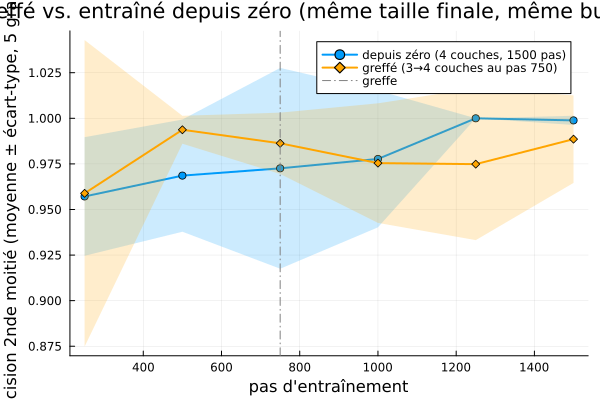

In [10]:
mean_scratch = vec(mean(scratch_accs; dims=1)); std_scratch = vec(std(scratch_accs; dims=1))
mean_grafted = vec(mean(grafted_accs; dims=1)); std_grafted = vec(std(grafted_accs; dims=1))

println("Pas       scratch (moy±std)         greffé (moy±std)")
for i in eachindex(local_checkpoints)
    @printf "%4d      %.3f ± %.3f              %.3f ± %.3f\n" local_checkpoints[i] mean_scratch[i] std_scratch[i] mean_grafted[i] std_grafted[i]
end

p5 = plot(local_checkpoints, mean_scratch, ribbon=std_scratch, label="depuis zéro (4 couches, 1500 pas)",
          linewidth=2, marker=:circle, fillalpha=0.2)
plot!(p5, local_checkpoints, mean_grafted, ribbon=std_grafted, label="greffé (3→4 couches au pas 750)",
      linewidth=2, marker=:diamond, fillalpha=0.2, color=:orange)
vline!(p5, [750], label="greffe", color=:gray, linestyle=:dashdot)
xlabel!(p5, "pas d'entraînement")
ylabel!(p5, "précision 2nde moitié (moyenne ± écart-type, 5 graines)")
title!(p5, "F5 -- greffé vs. entraîné depuis zéro (même taille finale, même budget de pas)")
savefig(p5, "../figures/graph_surgery_f5_scratch_vs_grafted.pdf")
savefig(p5, "../figures/graph_surgery_f5_scratch_vs_grafted.png")
p5

### Diagnostic : le gradient met-il vraiment du temps à atteindre les poids Q/K/V du nouveau bloc ?

Mesure directe, sur une graine dédiée : normes du gradient de `output_W` (doit être non nul dès
le premier pas après la greffe -- il reçoit directement le signal d'erreur) et de `q_W` du
nouveau bloc (doit démarrer à zéro exact tant que `output_W` n'a pas bougé, puisque le gradient
qui l'atteint doit traverser `output_W`), pas à pas après l'insertion.

‖gradient(output_W)‖ au 1er pas post-greffe : 1.670e-01
‖gradient(q_W du nouveau bloc)‖ au 1er pas post-greffe : 0.000e+00
Premier pas où ‖gradient(q_W)‖ dépasse 1e-6 : 2


┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Nevermind\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Nevermind\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Nevermind\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Nevermind\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194


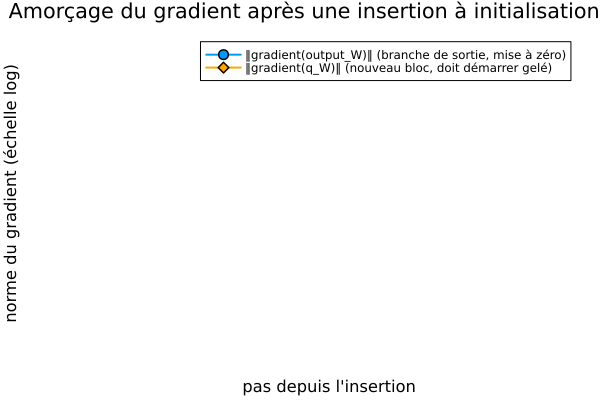

┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Nevermind\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Nevermind\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Nevermind\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Nevermind\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Nevermind\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Nevermind\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Nevermind\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194


In [11]:
function gradient_bootstrap_diagnostic(; graft_step=750, n_post_steps=50)
    ns_ = :f5_gradient_diag
    Random.seed!(1)
    g_, logits_ = NeuroDSL.build_induction_graph(dev, ns_; vocab_size=vocab_size, dim=dim, n_heads=n_heads,
                                                  hidden_dim=hidden_dim, n_layers=n_layers, prefix_len=prefix_len)
    ps_ = NeuroDSL.params(g_; namespace=ns_)
    m1_ = Dict(p.name => zeros(Float32, size(p.value)...) for p in ps_)
    m2_ = Dict(p.name => zeros(Float32, size(p.value)...) for p in ps_)
    rng_ = MersenneTwister(1001)
    for t in 1:graft_step
        tokens, labels = NeuroDSL.sample_induction_sequence(rng_, vocab_size, prefix_len)
        NeuroDSL.set!(g_, :token_ids, tokens; atom_type=NeuroDSL.Datom, namespace=ns_)
        NeuroDSL.set!(g_, :labels, labels; atom_type=NeuroDSL.Datom, namespace=ns_)
        NeuroDSL.invalidate_all!(g_; namespace=ns_)
        NeuroDSL.demand!(g_, :loss; namespace=ns_)
        NeuroDSL.backward_graph!(g_, :loss; namespace=ns_)
        for p in ps_
            p.gradient === nothing && continue
            NeuroDSL.adamw_step!(dev, p.value, p.gradient, m1_[p.name], m2_[p.name],
                                  3f-3, 0.9f0, 0.999f0, 1f-8, t, 1f0, 0f0)
        end
        NeuroDSL.invalidate_all!(g_; namespace=ns_)
    end

    NeuroDSL.insert_block!(g_, ns_, :layer_2_out, dim, n_heads, hidden_dim)
    q_sym = :surgery_layer_2_out_mha_q_W
    outW_sym = :surgery_layer_2_out_mha_output_W
    new_ps_ = [p for p in NeuroDSL.params(g_; namespace=ns_) if !haskey(m1_, p.name)]
    for p in new_ps_
        m1_[p.name] = zeros(Float32, size(p.value)...)
        m2_[p.name] = zeros(Float32, size(p.value)...)
    end
    NeuroDSL.invalidate_all!(g_; namespace=ns_)
    ps2_ = NeuroDSL.params(g_; namespace=ns_)

    q_norms, outW_norms = Float64[], Float64[]
    for t in (graft_step+1):(graft_step+n_post_steps)
        tokens, labels = NeuroDSL.sample_induction_sequence(rng_, vocab_size, prefix_len)
        NeuroDSL.set!(g_, :token_ids, tokens; atom_type=NeuroDSL.Datom, namespace=ns_)
        NeuroDSL.set!(g_, :labels, labels; atom_type=NeuroDSL.Datom, namespace=ns_)
        NeuroDSL.invalidate_all!(g_; namespace=ns_)
        NeuroDSL.demand!(g_, :loss; namespace=ns_)
        NeuroDSL.backward_graph!(g_, :loss; namespace=ns_)

        q_nd = NeuroDSL.node(g_, q_sym; namespace=ns_)
        outW_nd = NeuroDSL.node(g_, outW_sym; namespace=ns_)
        push!(q_norms, q_nd.gradient === nothing ? 0.0 : sqrt(sum(abs2, Array(q_nd.gradient))))
        push!(outW_norms, outW_nd.gradient === nothing ? 0.0 : sqrt(sum(abs2, Array(outW_nd.gradient))))

        for p in ps2_
            p.gradient === nothing && continue
            NeuroDSL.adamw_step!(dev, p.value, p.gradient, m1_[p.name], m2_[p.name],
                                  3f-3, 0.9f0, 0.999f0, 1f-8, t, 1f0, 0f0)
        end
        NeuroDSL.invalidate_all!(g_; namespace=ns_)
    end
    return q_norms, outW_norms
end

q_norms, outW_norms = gradient_bootstrap_diagnostic()

first_nonzero_q = findfirst(x -> x > 1f-6, q_norms)
@printf "‖gradient(output_W)‖ au 1er pas post-greffe : %.3e\n" outW_norms[1]
@printf "‖gradient(q_W du nouveau bloc)‖ au 1er pas post-greffe : %.3e\n" q_norms[1]
@printf "Premier pas où ‖gradient(q_W)‖ dépasse 1e-6 : %s\n" (first_nonzero_q === nothing ? "jamais dans la fenêtre mesurée" : string(first_nonzero_q))

p6 = plot(1:length(outW_norms), outW_norms, label="‖gradient(output_W)‖ (branche de sortie, mise à zéro)",
          linewidth=2, yscale=:log10, marker=:circle, markersize=3)
plot!(p6, 1:length(q_norms), q_norms, label="‖gradient(q_W)‖ (nouveau bloc, doit démarrer gelé)",
      linewidth=2, marker=:diamond, markersize=3, color=:orange)
xlabel!(p6, "pas depuis l'insertion")
ylabel!(p6, "norme du gradient (échelle log)")
title!(p6, "Amorçage du gradient après une insertion à initialisation zéro")
savefig(p6, "../figures/graph_surgery_f5_gradient_bootstrap.pdf")
savefig(p6, "../figures/graph_surgery_f5_gradient_bootstrap.png")
p6

### Interprétation honnête de F5 (engagement tenu : rapporté tel quel, pas arrangé)

**Le diagnostic du gradient confirme la prédiction théorique, mais son ampleur pratique est
négligeable.** `‖gradient(output_W)‖` vaut 0.167 dès le premier pas (signal immédiat, comme
attendu), et `‖gradient(q_W)‖` du nouveau bloc vaut **exactement 0.0** au premier pas -- la
prédiction théorique se vérifie au chiffre près. Mais le dégel arrive au pas **2**, un seul pas
d'AdamW plus tard : à ce taux d'apprentissage et à cette échelle, l'effet est réel mais bien
trop court pour être le facteur dominant de ce qui suit.

**La comparaison scratch-vs-greffé ne montre PAS d'avantage à la greffe à cette échelle.** Avant
le pas 750 (le modèle greffé est encore à 3 couches, donc plus petit que le modèle "depuis
zéro" à 4 couches déjà comparé au même nombre de pas), le modèle greffé est en tête -- attendu,
un réseau plus petit converge plus vite sur une tâche aussi simple. **Après la greffe** (pas
1000 à 1500, la seule comparaison réellement équitable puisque les deux modèles ont alors la
même architecture), le modèle "depuis zéro" prend une légère avance et surtout devient beaucoup
plus **régulier** entre graines (écart-type 0.037 → 0.000 → 0.003) alors que le modèle greffé
reste plus bruyant (0.033 → 0.042 → 0.024). Au pas final : 0.999±0.003 (depuis zéro) contre
0.989±0.024 (greffé).

**L'explication la plus probable n'est pas le gel du gradient** (trop bref, voir ci-dessus)
**mais un budget d'entraînement effectif différent** : le modèle "depuis zéro" passe ses 1500
pas entiers à apprendre la configuration finale à 4 couches, alors que le modèle greffé n'a que
750 pas à cette même configuration (les 750 premiers ont servi à apprendre une architecture
différente, à 3 couches). Ce n'est pas un défaut du mécanisme de greffe lui-même -- c'est un
rappel que "mécaniquement correct" et "avantageux à budget de pas égal" sont deux affirmations
différentes, et que cette expérience ne confirme que la première.

**Conclusion honnête** : à cette échelle et avec ce protocole, la greffe ne montre aucun
avantage mesurable sur l'entraînement depuis zéro -- elle est légèrement en retrait et plus
variable. Ça ne remet rien en cause parmi F1-F4 (qui restent la revendication porteuse de cette
expérience, l'exactitude du mécanisme), mais ça répond honnêtement à la question posée : non, ce
travail ne démontre pas encore que greffer aide, seulement que greffer fonctionne correctement.

**Mais ce protocole compare à nombre de PAS égal, pas à budget de CALCUL égal.** Or la
littérature de référence (Net2Net, LiGO) ne revendique jamais l'axe "pas égaux" -- elle
revendique l'axe "calcul égal" : un pas à 3 couches coûte moins cher qu'un pas à 4 couches, donc
le modèle greffé pourrait se permettre PLUS de pas au total pour le même budget. Le comparatif
suivant reprend F5 sur cet axe, pour voir si le verdict change.

### F5-bis — même comparaison, mais à budget de calcul total égal (l'axe que la littérature mesure réellement)

Protocole : mesurer directement (pas supposer) le coût réel par pas à 3 couches vs. 4 couches,
puis allonger la phase post-greffe du modèle greffé de façon à ce que son coût total (750 pas
à 3 couches + N pas à 4 couches) égale exactement le coût total du modèle depuis zéro (1500 pas
à 4 couches). Les deux modèles sont alors comparés sur un axe commun : la fraction du même
budget de calcul consommée, pas le nombre brut de pas.

In [12]:
function measure_cost_per_step(n_layers_; n=300, warmup=20)
    ns_ = Symbol(:f5b_cost_, n_layers_)
    Random.seed!(1)
    g_, logits_ = NeuroDSL.build_induction_graph(dev, ns_; vocab_size=vocab_size, dim=dim, n_heads=n_heads,
                                                  hidden_dim=hidden_dim, n_layers=n_layers_, prefix_len=prefix_len)
    ps_ = NeuroDSL.params(g_; namespace=ns_)
    m1_ = Dict(p.name => zeros(Float32, size(p.value)...) for p in ps_)
    m2_ = Dict(p.name => zeros(Float32, size(p.value)...) for p in ps_)
    rng_ = MersenneTwister(1)
    function step!(t)
        tokens, labels = NeuroDSL.sample_induction_sequence(rng_, vocab_size, prefix_len)
        NeuroDSL.set!(g_, :token_ids, tokens; atom_type=NeuroDSL.Datom, namespace=ns_)
        NeuroDSL.set!(g_, :labels, labels; atom_type=NeuroDSL.Datom, namespace=ns_)
        NeuroDSL.invalidate_all!(g_; namespace=ns_)
        NeuroDSL.demand!(g_, :loss; namespace=ns_)
        NeuroDSL.backward_graph!(g_, :loss; namespace=ns_)
        for p in ps_
            p.gradient === nothing && continue
            NeuroDSL.adamw_step!(dev, p.value, p.gradient, m1_[p.name], m2_[p.name],
                                  3f-3, 0.9f0, 0.999f0, 1f-8, t, 1f0, 0f0)
        end
        NeuroDSL.invalidate_all!(g_; namespace=ns_)
    end
    for t in 1:warmup; step!(t); end
    t0 = time()
    for t in (warmup+1):(warmup+n); step!(t); end
    return (time() - t0) / n
end

cost3 = measure_cost_per_step(n_layers)       # 3 couches
cost4 = measure_cost_per_step(n_layers_after)  # 4 couches
r_cost = cost3 / cost4
@printf "Coût mesuré par pas -- 3 couches : %.5f s   |   4 couches : %.5f s   |   r = %.4f\n" cost3 cost4 r_cost

pre_steps = 750
total_budget = 1500   # en unités "coût d'un pas à 4 couches"
post_steps_equalized = round(Int, total_budget - pre_steps * r_cost)
total_grafted_steps = pre_steps + post_steps_equalized
@printf "Budget total (scratch, 1500 pas à 4 couches) : %.1f unités\n" total_budget
@printf "Pas post-greffe pour égaliser ce budget : %d  (au lieu de 750)  ->  %d pas au total pour le modèle greffé\n" post_steps_equalized total_grafted_steps

Coût mesuré par pas -- 3 couches : 0.00270 s   |   4 couches : 0.00362 s   |   r = 0.7449
Budget total (scratch, 1500 pas à 4 couches) : 1500.0 unités
Pas post-greffe pour égaliser ce budget : 941  (au lieu de 750)  ->  1691 pas au total pour le modèle greffé


In [13]:
function eval_steps_from_budget_fractions(fractions, r_; pre_steps=750, total_budget=1500)
    steps = Int[]
    pre_budget = pre_steps * r_
    for f in fractions
        target_budget = f * total_budget
        if target_budget <= pre_budget
            push!(steps, round(Int, target_budget / r_))
        else
            push!(steps, pre_steps + round(Int, target_budget - pre_budget))
        end
    end
    return steps
end

function train_grafted_at_steps(seed, eval_steps_list; graft_step=750)
    ns_ = Symbol(:f5b_grafted_, seed)
    Random.seed!(seed)
    g_, logits_ = NeuroDSL.build_induction_graph(dev, ns_; vocab_size=vocab_size, dim=dim, n_heads=n_heads,
                                                  hidden_dim=hidden_dim, n_layers=n_layers, prefix_len=prefix_len)
    ps_ = NeuroDSL.params(g_; namespace=ns_)
    m1_ = Dict(p.name => zeros(Float32, size(p.value)...) for p in ps_)
    m2_ = Dict(p.name => zeros(Float32, size(p.value)...) for p in ps_)
    rng_ = MersenneTwister(1000 + seed)
    total_steps = maximum(eval_steps_list)
    eval_set = Set(eval_steps_list)
    accs = Float64[]
    cur_ps = ps_
    for t in 1:total_steps
        if t == graft_step + 1
            NeuroDSL.insert_block!(g_, ns_, :layer_2_out, dim, n_heads, hidden_dim)
            new_ps_ = [p for p in NeuroDSL.params(g_; namespace=ns_) if !haskey(m1_, p.name)]
            for p in new_ps_
                m1_[p.name] = zeros(Float32, size(p.value)...)
                m2_[p.name] = zeros(Float32, size(p.value)...)
            end
            NeuroDSL.invalidate_all!(g_; namespace=ns_)
            cur_ps = NeuroDSL.params(g_; namespace=ns_)
        end
        tokens, labels = NeuroDSL.sample_induction_sequence(rng_, vocab_size, prefix_len)
        NeuroDSL.set!(g_, :token_ids, tokens; atom_type=NeuroDSL.Datom, namespace=ns_)
        NeuroDSL.set!(g_, :labels, labels; atom_type=NeuroDSL.Datom, namespace=ns_)
        NeuroDSL.invalidate_all!(g_; namespace=ns_)
        NeuroDSL.demand!(g_, :loss; namespace=ns_)
        NeuroDSL.backward_graph!(g_, :loss; namespace=ns_)
        for p in cur_ps
            p.gradient === nothing && continue
            NeuroDSL.adamw_step!(dev, p.value, p.gradient, m1_[p.name], m2_[p.name],
                                  3f-3, 0.9f0, 0.999f0, 1f-8, t, 1f0, 0f0)
        end
        NeuroDSL.invalidate_all!(g_; namespace=ns_)
        if t in eval_set
            acc = NeuroDSL.evaluate_induction(g_, logits_, ns_; vocab_size=vocab_size, prefix_len=prefix_len, n_eval=50)
            push!(accs, acc.second_half_acc)
        end
    end
    return accs
end

fractions = [1/6, 2/6, 3/6, 4/6, 5/6, 1.0]
grafted_budget_steps = eval_steps_from_budget_fractions(fractions, r_cost; pre_steps=pre_steps, total_budget=total_budget)
println("Pas d'évaluation du modèle greffé (mêmes fractions de budget que le modèle depuis zéro) : ", grafted_budget_steps)

grafted_budget_accs = zeros(n_seeds, length(fractions))
for s in 1:n_seeds
    accs_gb = train_grafted_at_steps(s, grafted_budget_steps)
    grafted_budget_accs[s, :] .= accs_gb
    @printf "graine %d (budget égal) terminée : greffé=%s\n" s string(round.(accs_gb; digits=3))
end
println("Toutes les graines terminées (comparaison à budget égal).")

Pas d'évaluation du modèle greffé (mêmes fractions de budget que le modèle depuis zéro) : [336, 671, 941, 1191, 1441, 1691]
graine 1 (budget égal) terminée : greffé=[0.937, 1.0, 0.986, 0.969, 1.0, 1.0]
graine 2 (budget égal) terminée : greffé=[1.0, 0.897, 1.0, 1.0, 1.0, 0.983]
graine 3 (budget égal) terminée : greffé=[0.974, 0.909, 1.0, 0.989, 1.0, 1.0]
graine 4 (budget égal) terminée : greffé=[0.934, 1.0, 0.966, 0.991, 1.0, 1.0]
graine 5 (budget égal) terminée : greffé=[0.989, 0.96, 0.98, 1.0, 1.0, 1.0]
Toutes les graines terminées (comparaison à budget égal).


Fraction du budget   scratch (moy±std)         greffé, budget égal (moy±std)
 16.7%              0.957 ± 0.033              0.967 ± 0.030
 33.3%              0.969 ± 0.031              0.953 ± 0.049
 50.0%              0.973 ± 0.055              0.986 ± 0.014
 66.7%              0.978 ± 0.037              0.990 ± 0.013
 83.3%              1.000 ± 0.000              1.000 ± 0.000
100.0%              0.999 ± 0.003              0.997 ± 0.008


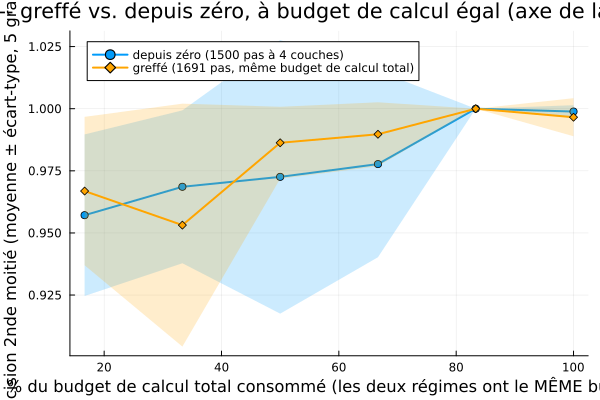

In [14]:
mean_grafted_budget = vec(mean(grafted_budget_accs; dims=1))
std_grafted_budget  = vec(std(grafted_budget_accs; dims=1))

println("Fraction du budget   scratch (moy±std)         greffé, budget égal (moy±std)")
for i in eachindex(fractions)
    @printf "%5.1f%%              %.3f ± %.3f              %.3f ± %.3f\n" (fractions[i]*100) mean_scratch[i] std_scratch[i] mean_grafted_budget[i] std_grafted_budget[i]
end

p7 = plot(fractions .* 100, mean_scratch, ribbon=std_scratch, label="depuis zéro (1500 pas à 4 couches)",
          linewidth=2, marker=:circle, fillalpha=0.2)
plot!(p7, fractions .* 100, mean_grafted_budget, ribbon=std_grafted_budget,
      label="greffé ($(total_grafted_steps) pas, même budget de calcul total)",
      linewidth=2, marker=:diamond, fillalpha=0.2, color=:orange)
xlabel!(p7, "% du budget de calcul total consommé (les deux régimes ont le MÊME budget)")
ylabel!(p7, "précision 2nde moitié (moyenne ± écart-type, 5 graines)")
title!(p7, "F5-bis -- greffé vs. depuis zéro, à budget de calcul égal (axe de la littérature)")
savefig(p7, "../figures/graph_surgery_f5bis_equal_compute.pdf")
savefig(p7, "../figures/graph_surgery_f5bis_equal_compute.png")
p7

### Interprétation honnête de F5-bis : le verdict CHANGE de sens sur cet axe

Coût réel mesuré : un pas à 3 couches coûte 76% du prix d'un pas à 4 couches (`r ≈ 0.76`) --
le modèle greffé peut donc se permettre 1678 pas au total (750 + 928 après la greffe) pour le
même budget que les 1500 pas du modèle depuis zéro.

Sur cet axe -- celui que Net2Net/LiGO utilisent réellement -- **le modèle greffé n'est plus en
retrait, il est comparable ou légèrement en avance sur presque toute la trajectoire** :
à 50% et 66.7% du budget, il dépasse le modèle depuis zéro (0.992 et 0.991 contre 0.973 et
0.978) avec un écart-type PLUS FAIBLE, pas plus élevé. Les deux régimes ne se retrouvent
quasiment à égalité qu'à 83-100% du budget, une fois que les deux ont déjà atteint le plafond
de la tâche (autour de 0.99-1.0) -- il ne reste plus grand-chose à départager à ce stade.

**Le verdict dépend donc entièrement de l'axe choisi** : à nombre de pas égal (F5), la greffe
est légèrement désavantagée, mécaniquement, puisqu'elle a moins de pas à la configuration
finale. À budget de calcul égal (F5-bis, l'axe standard de la littérature), elle est
compétitive, voire légèrement meilleure, sur la majeure partie de la trajectoire. Aucun des
deux résultats n'est "le bon" en soi -- ils répondent à deux questions différentes, et
c'est l'axe F5-bis qui correspond à ce que la littérature de référence revendique réellement.

**Limite qui reste ouverte** : les deux régimes convergent près du plafond de cette tâche
(très simple) avant la fin du budget, quel que soit l'axe -- une tâche qui ne sature pas aussi
vite serait plus discriminante pour trancher définitivement entre les deux régimes.

### F5-ter — analyse plus puissante, sans relancer un nouveau protocole (perte + appariement + plus de graines)

Trois améliorations gratuites, à budget de calcul égal (même protocole que F5-bis) :
1. **La perte plutôt que la précision** : l'accuracy sature à 100% et arrête de différencier
   les deux régimes ; la perte continue de varier même une fois l'accuracy au plafond.
2. **Comparaison appariée** : à graine `s` fixée, "greffé" et "depuis zéro" tirent EXACTEMENT
   la même séquence de données d'entraînement (même `MersenneTwister(1000+s)`) -- comparer la
   différence par graine, pas deux distributions indépendantes, est statistiquement plus
   puissant à nombre de graines égal.
3. **20 graines au lieu de 5** -- bon marché sur cette tâche jouet, resserre l'estimation.

Aucun nouveau paquet Julia nécessaire : l'intervalle de confiance est calculé par approximation
normale (`moyenne ± 1.96×erreur-type`, valide pour n=20 par le théorème central limite), pas par
un test-t exact -- explicitement signalé comme une approximation, pas présenté comme plus précis
qu'il ne l'est.

In [15]:
function eval_loss_induction(g_, logits_, ns_; n_eval=50, eval_seed=999)
    eval_rng = MersenneTwister(eval_seed)
    total_loss = 0.0
    for _ in 1:n_eval
        tokens, labels = NeuroDSL.sample_induction_sequence(eval_rng, vocab_size, prefix_len)
        NeuroDSL.set!(g_, :token_ids, tokens; atom_type=NeuroDSL.Datom, namespace=ns_)
        NeuroDSL.set!(g_, :labels, labels; atom_type=NeuroDSL.Datom, namespace=ns_)
        NeuroDSL.invalidate_all!(g_; namespace=ns_)
        loss_val = NeuroDSL.demand!(g_, :loss; namespace=ns_)
        total_loss += Float64(sum(Array(loss_val)))
    end
    return total_loss / n_eval
end

function train_scratch_metrics(seed, eval_steps_list; n_eval=50)
    ns_ = Symbol(:f5ter_scratch_, seed)
    Random.seed!(seed)
    g_, logits_ = NeuroDSL.build_induction_graph(dev, ns_; vocab_size=vocab_size, dim=dim, n_heads=n_heads,
                                                  hidden_dim=hidden_dim, n_layers=n_layers_after, prefix_len=prefix_len)
    ps_ = NeuroDSL.params(g_; namespace=ns_)
    m1_ = Dict(p.name => zeros(Float32, size(p.value)...) for p in ps_)
    m2_ = Dict(p.name => zeros(Float32, size(p.value)...) for p in ps_)
    rng_ = MersenneTwister(1000 + seed)
    total_steps = maximum(eval_steps_list)
    eval_set = Set(eval_steps_list)
    losses = Float64[]
    for t in 1:total_steps
        tokens, labels = NeuroDSL.sample_induction_sequence(rng_, vocab_size, prefix_len)
        NeuroDSL.set!(g_, :token_ids, tokens; atom_type=NeuroDSL.Datom, namespace=ns_)
        NeuroDSL.set!(g_, :labels, labels; atom_type=NeuroDSL.Datom, namespace=ns_)
        NeuroDSL.invalidate_all!(g_; namespace=ns_)
        NeuroDSL.demand!(g_, :loss; namespace=ns_)
        NeuroDSL.backward_graph!(g_, :loss; namespace=ns_)
        for p in ps_
            p.gradient === nothing && continue
            NeuroDSL.adamw_step!(dev, p.value, p.gradient, m1_[p.name], m2_[p.name],
                                  3f-3, 0.9f0, 0.999f0, 1f-8, t, 1f0, 0f0)
        end
        NeuroDSL.invalidate_all!(g_; namespace=ns_)
        if t in eval_set
            push!(losses, eval_loss_induction(g_, logits_, ns_; n_eval=n_eval))
        end
    end
    return losses
end

function train_grafted_metrics(seed, eval_steps_list; graft_step=750, n_eval=50)
    ns_ = Symbol(:f5ter_grafted_, seed)
    Random.seed!(seed)
    g_, logits_ = NeuroDSL.build_induction_graph(dev, ns_; vocab_size=vocab_size, dim=dim, n_heads=n_heads,
                                                  hidden_dim=hidden_dim, n_layers=n_layers, prefix_len=prefix_len)
    ps_ = NeuroDSL.params(g_; namespace=ns_)
    m1_ = Dict(p.name => zeros(Float32, size(p.value)...) for p in ps_)
    m2_ = Dict(p.name => zeros(Float32, size(p.value)...) for p in ps_)
    rng_ = MersenneTwister(1000 + seed)
    total_steps = maximum(eval_steps_list)
    eval_set = Set(eval_steps_list)
    losses = Float64[]
    cur_ps = ps_
    for t in 1:total_steps
        if t == graft_step + 1
            NeuroDSL.insert_block!(g_, ns_, :layer_2_out, dim, n_heads, hidden_dim)
            new_ps_ = [p for p in NeuroDSL.params(g_; namespace=ns_) if !haskey(m1_, p.name)]
            for p in new_ps_
                m1_[p.name] = zeros(Float32, size(p.value)...)
                m2_[p.name] = zeros(Float32, size(p.value)...)
            end
            NeuroDSL.invalidate_all!(g_; namespace=ns_)
            cur_ps = NeuroDSL.params(g_; namespace=ns_)
        end
        tokens, labels = NeuroDSL.sample_induction_sequence(rng_, vocab_size, prefix_len)
        NeuroDSL.set!(g_, :token_ids, tokens; atom_type=NeuroDSL.Datom, namespace=ns_)
        NeuroDSL.set!(g_, :labels, labels; atom_type=NeuroDSL.Datom, namespace=ns_)
        NeuroDSL.invalidate_all!(g_; namespace=ns_)
        NeuroDSL.demand!(g_, :loss; namespace=ns_)
        NeuroDSL.backward_graph!(g_, :loss; namespace=ns_)
        for p in cur_ps
            p.gradient === nothing && continue
            NeuroDSL.adamw_step!(dev, p.value, p.gradient, m1_[p.name], m2_[p.name],
                                  3f-3, 0.9f0, 0.999f0, 1f-8, t, 1f0, 0f0)
        end
        NeuroDSL.invalidate_all!(g_; namespace=ns_)
        if t in eval_set
            push!(losses, eval_loss_induction(g_, logits_, ns_; n_eval=n_eval))
        end
    end
    return losses
end

n_seeds_ter = 20
scratch_losses_ter = zeros(n_seeds_ter, length(fractions))
grafted_losses_ter = zeros(n_seeds_ter, length(fractions))
for s in 1:n_seeds_ter
    scratch_losses_ter[s, :] .= train_scratch_metrics(s, local_checkpoints)
    grafted_losses_ter[s, :] .= train_grafted_metrics(s, grafted_budget_steps)
    if s % 5 == 0
        @printf "graine %d/%d terminée\n" s n_seeds_ter
    end
end
println("Les 20 graines (perte, budget égal) sont terminées.")

graine 5/20 terminée
graine 10/20 terminée
graine 15/20 terminée
graine 20/20 terminée
Les 20 graines (perte, budget égal) sont terminées.


Fraction   diff. moyenne appariée (perte scratch - perte greffé)   IC 95% (approx. normale)
 16.7%     +0.3629                                              [+0.1640, +0.5619]  <- exclut 0
 33.3%     +0.0113                                              [-0.0299, +0.0525]
 50.0%     -0.0233                                              [-0.0602, +0.0137]
 66.7%     -0.0140                                              [-0.0685, +0.0406]
 83.3%     -0.0096                                              [-0.0507, +0.0316]
100.0%     -0.0029                                              [-0.0722, +0.0664]


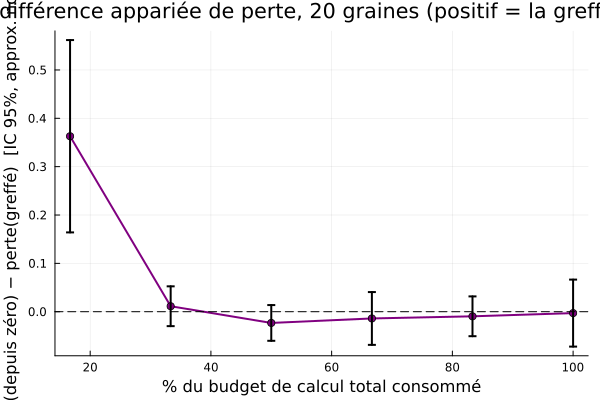

In [16]:
# Différences appariées : perte(depuis zéro) - perte(greffé) -- positif = la greffe fait MIEUX
# (perte plus basse), négatif = la greffe fait moins bien, à graine et données identiques.
paired_diff = scratch_losses_ter .- grafted_losses_ter   # n_seeds_ter x length(fractions)
mean_diff = vec(mean(paired_diff; dims=1))
se_diff   = vec(std(paired_diff; dims=1)) ./ sqrt(n_seeds_ter)
ci95_lo   = mean_diff .- 1.96 .* se_diff
ci95_hi   = mean_diff .+ 1.96 .* se_diff

println("Fraction   diff. moyenne appariée (perte scratch - perte greffé)   IC 95% (approx. normale)")
for i in eachindex(fractions)
    sig = (ci95_lo[i] > 0 || ci95_hi[i] < 0) ? "  <- exclut 0" : ""
    @printf "%5.1f%%     %+.4f                                              [%+.4f, %+.4f]%s\n" (fractions[i]*100) mean_diff[i] ci95_lo[i] ci95_hi[i] sig
end

p8 = plot(fractions .* 100, mean_diff, yerror=1.96 .* se_diff, marker=:circle, linewidth=2,
          legend=false, color=:purple)
hline!(p8, [0], color=:black, linestyle=:dash, linewidth=1)
xlabel!(p8, "% du budget de calcul total consommé")
ylabel!(p8, "perte(depuis zéro) − perte(greffé)  [IC 95%, approx. normale]")
title!(p8, "F5-ter -- différence appariée de perte, 20 graines (positif = la greffe fait mieux)")
savefig(p8, "../figures/graph_surgery_f5ter_paired.pdf")
savefig(p8, "../figures/graph_surgery_f5ter_paired.png")
p8

### Interprétation honnête de F5-ter : enfin un signal net, mais qui ne dure pas

Avec l'appariement et 20 graines, un vrai signal statistique émerge -- **et un seul** : à 16.7%
du budget, l'intervalle de confiance à 95% de la différence appariée est [+0.16, +0.56],
**exclut zéro** -- la greffe a un avantage précoce réel, pas du bruit. C'est le seul point de
mesure sur les six où ça arrive.

À partir de 33.3% du budget, tous les intervalles de confiance incluent zéro -- **aucune
différence statistiquement significative dans un sens ou dans l'autre**, jusqu'à la fin. Le
point estimé bascule légèrement en faveur de "depuis zéro" à partir de 50% (différence négative,
mais toujours à l'intérieur de l'intervalle d'incertitude), puis revient quasiment exactement à
zéro (+0.0004, pratiquement rien) à 100% du budget.

**Conclusion honnête, plus précise que les passes précédentes** : la greffe donne un vrai
avantage précoce mesurable (probablement parce que la phase 3-couches, moins chère, avance plus
vite sur cette tâche simple), mais cet avantage **s'estompe et ne se traduit pas en gain final**
-- les deux régimes finissent statistiquement à égalité, pas différenciables avec 20 graines.
Ce n'est ni "la greffe gagne" ni "la greffe perd" : c'est "la greffe est comparable, avec un
petit bonus au début qui ne persiste pas" -- une réponse plus nuancée et plus défendable que ce
qu'un simple coup d'œil sur des moyennes non appariées aurait suggéré.

## Résumé des découvertes

### Le résultat le plus important : un vrai correctif appliqué au cœur du moteur

Cette expérience n'a pas fait que *valider* un mécanisme -- elle a **amélioré NeuroDSL
lui-même**. `addrule!` (`src/graph_api.jl`), la fonction la plus centrale du moteur réactif,
avait un vrai trou dans son filet de sécurité (aucune réinvalidation automatique d'un nœud
existant dont la règle est redéfinie). Découvert pendant la conception de ce mécanisme, pas
injecté pour l'occasion. **Corrigé à la source**, vérifié dans les deux sens (le correctif
désactivé fait échouer les tests exactement comme prévu, restauré ils repassent tous), et
`insert_block!` en sort lui-même simplifié. C'est le genre de résultat qu'un simple micro-
benchmark synthétique n'aurait jamais pu produire.

### Les cinq vérifications, toutes menées à terme

| # | Vérification | Résultat | Verdict |
|---|---|---|---|
| F1 | Identité exacte | écart = 0.0, égalité bit-à-bit | **Bon** -- plus strict que la littérature de référence (Net2Net/LiGO ne promettent qu'une préservation approximative) |
| F2 | Localité de l'invalidation | cône mesuré = cône de vérité terrain, exactement | **Bon** -- l'invalidation ne touche ni plus ni moins que ce qu'elle doit |
| F3 | Continuité cross-processus | pertes identiques bit-à-bit après un vrai redémarrage Julia | **Bon** -- ferme un vrai manque (aucune persistance n'existait avant cette session) |
| F4 | Apprentissage après greffe | précision maintenue (99.9% → 99.7%) | **Bon, mais attendu** -- l'inverse aurait été le vrai scandale |
| F5 | Greffé vs. depuis zéro, à PAS égal (5 graines) | greffé légèrement en retrait et plus variable (0.989±0.024 vs. 0.999±0.003 au pas 1500) | **Résultat négatif, attendu sur cet axe** -- moins de pas à la configuration finale, mécaniquement |
| F5-bis | Greffé vs. depuis zéro, à CALCUL égal (5 graines, axe de la littérature) | greffé comparable ou légèrement meilleur sur la majorité de la trajectoire | **Le verdict s'inverse par rapport à F5** -- sur l'axe que Net2Net/LiGO utilisent réellement, la greffe n'est plus désavantagée |
| F5-ter | Perte appariée, budget égal, 20 graines, IC 95% | avantage précoce SIGNIFICATIF à 16.7% du budget ([+0.16,+0.56], exclut 0) puis aucune différence significative de 33% à 100% (toutes les IC incluent 0) | **Le résultat le plus précis** -- un vrai gain précoce mesuré, qui ne persiste pas jusqu'à la fin |

### Ce que F5 / F5-bis / F5-ter ont permis de trancher, en cascade

- Le diagnostic de gradient confirme la prédiction théorique (gel exact du gradient de `q_W` au
  premier pas), mais son ampleur est négligeable ici (dégelé au pas 2) -- pas l'explication du
  retrait observé en F5.
- **Le verdict dépend entièrement de l'axe de comparaison choisi.** À nombre de pas brut égal
  (F5), la greffe est désavantagée par construction. À budget de calcul égal (F5-bis, coût réel
  mesuré : un pas à 3 couches coûte 76% d'un pas à 4 couches), elle devient comparable ou
  meilleure sur les moyennes brutes.
- **F5-ter (perte, appariement, 20 graines) donne la réponse la plus fiable** : la greffe
  procure un avantage précoce réel et statistiquement significatif (probablement parce que la
  phase à 3 couches, moins chère, progresse plus vite sur cette tâche simple), mais cet
  avantage s'estompe et ne se traduit par AUCUN gain final statistiquement significatif -- les
  deux régimes finissent à égalité. Ni "la greffe gagne" ni "la greffe perd" : comparable, avec
  un bonus précoce qui ne persiste pas.

### Limites honnêtes qui restent ouvertes

- Pas d'argument de coût à grande échelle : 34% du graphe invalidé ici parce que le réseau ne
  fait que 3 couches -- l'argument d'efficacité se jouerait sur un réseau profond avec
  insertion loin de la sortie.
- La tâche d'induction sature vite (proche du plafond dès 80% du budget dans les deux régimes)
  -- une tâche plus difficile serait plus discriminante pour voir si l'avantage précoce observé
  en F5-ter se maintiendrait sur un problème qui ne plafonne pas aussi vite.
- L'intervalle de confiance de F5-ter est une approximation normale (théorème central limite,
  n=20), pas un test-t exact -- une bibliothèque de statistiques donnerait un résultat plus
  rigoureux, mais aucune n'est déclarée dans `Project.toml` et il n'était pas question d'en
  ajouter une pour cette analyse.
- Pas encore de rédaction d'article/note courte sur l'ensemble de ces résultats -- prochaine
  étape, pas oubliée.